# Judge Comparisons - ROC-AUC Analysis

This notebook compares multiple judges against ROUGE-L continuous scores using ROC-AUC curves.
Each judge's binary classifications are evaluated against the continuous ROUGE-L scores from the reference collections.


In [10]:
import polars as pl
import matplotlib.pyplot as plt
from sklearn import metrics
import os
import json
from pathlib import Path

# Define paths
PROCESSED_COLLECTIONS_PATH = "processed_collections"
REFERENCE_COLLECTIONS_PATH = "reference_collections"
AGGREGATIONS_PATH = "aggregations"

# Ensure aggregations folder exists
os.makedirs(AGGREGATIONS_PATH, exist_ok=True)

# Model folder names (on disk) to display names mapping
MODEL_FOLDER_NAMES = ["llama", "llama_default", "qwen", "qwen_default"]
MODEL_DISPLAY_NAMES = ["llama_extraction", "llama_instruction", "qwen_extraction", "qwen_instruction"]
MODELS = dict(zip(MODEL_FOLDER_NAMES, MODEL_DISPLAY_NAMES))  # {'llama': 'llama_extraction', ...}

# Judge names mapping
JUDGE_KEYS = ["naive", "pairwise_rag_judge", "pairwise_zeroshot_judge", "voting_naive"]
JUDGES = {
    "naive": "Naive Judge",
    "pairwise_rag_judge": "Pairwise RAG",
    "pairwise_zeroshot_judge": "Pairwise ZeroShot",
    "voting_naive": "Voting Naive"
}

# Judge colors (in order of JUDGE_KEYS)
JUDGE_COLORS = {
    "naive": "#1b9e77",
    "pairwise_rag_judge": "#d95f02",
    "pairwise_zeroshot_judge": "#7570b3",
    "voting_naive": "#e7298a"
}

print("Environment setup complete.")

Environment setup complete.


## Analysis

This section evaluates the performance of four different judge implementations by comparing their binary classifications against continuous ROUGE-L scores. ROUGE-L (Recall-Oriented Understudy for Gisting Evaluation) is a standard metric for evaluating text generation quality based on the longest common subsequence between generated and reference text.

**Key Question**: Which judge best identifies high-quality context passages according to ROUGE-L scores?

**Evaluation Metric**: ROC-AUC (Area Under the Receiver Operating Characteristic Curve) measures the judge's ability to distinguish between high-quality (ROUGE-L > median) and low-quality passages. An AUC of 1.0 indicates perfect discrimination, while 0.5 represents random classification.



## Helper Function for ROC-AUC Computation

Define a function that properly handles data alignment (sorting and joining) before computing ROC-AUC scores.


In [ ]:
def compute_roc_auc_with_alignment(judge_df, reference_df, reference_score_col="evaluation"):
    """
    Compute ROC-AUC with proper data alignment.
    
    Parameters:
    -----------
    judge_df : polars.DataFrame
        Binary judge classifications with columns: collection_idx, test_idx, evaluation
    reference_df : polars.DataFrame
        Continuous reference scores with columns: collection_idx, test_idx, {reference_score_col}
    reference_score_col : str, default "evaluation"
        Name of the column in reference_df containing the continuous scores
    
    Returns:
    --------
    tuple : (roc_auc_score, fpr, tpr, thresholds)
    """
    # Sort both dataframes
    judge_sorted = judge_df.sort("collection_idx", "test_idx")
    reference_sorted = reference_df.sort("collection_idx", "test_idx")
    
    # Join on collection_idx and test_idx (inner join to keep only aligned records)
    merged_df = judge_sorted.join(
        reference_sorted.select(["collection_idx", "test_idx", reference_score_col]).rename({reference_score_col: "ref_score"}),
        on=["collection_idx", "test_idx"],
        how="inner"
    )
    
    # Extract labels and scores
    y_true = merged_df["evaluation"].to_list()  # Binary judge labels
    y_scores = merged_df["ref_score"].to_list()  # Continuous reference scores
    
    # Calculate ROC-AUC
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)
    
    return roc_auc, fpr, tpr, thresholds

print("Helper function updated.")

Helper function updated.


In [3]:
def load_judge_train_from_processed(model, judge_key, processed_collections_root=PROCESSED_COLLECTIONS_PATH):
    """
    Load judge train.feather from processed_collections.
    
    Parameters:
    -----------
    model : str
        Model name (e.g., 'llama', 'qwen')
    judge_key : str
        Judge type key (e.g., 'naive', 'pairwise_rag_judge')
    processed_collections_root : str
        Path to processed_collections directory
        
    Returns:
    --------
    polars.DataFrame
        Sorted judge data with columns: collection_idx, test_idx, evaluation
    """
    judge_path = os.path.join(processed_collections_root, model, judge_key, "train.feather")
    judge_df = pl.read_ipc(judge_path).filter(pl.col("evaluation").is_not_null()).sort("collection_idx", "test_idx")
    return judge_df


def load_reference_f1_train(model, reference_collections_root=REFERENCE_COLLECTIONS_PATH):
    """
    Load reference F1 train.feather from reference_collections.
    
    Parameters:
    -----------
    model : str
        Model name (e.g., 'llama', 'qwen')
    reference_collections_root : str
        Path to reference_collections directory
        
    Returns:
    --------
    polars.DataFrame
        Sorted reference data with columns: collection_idx, test_idx, evaluation
    """
    ref_path = os.path.join(reference_collections_root, model, "f1_collection", "train.feather")
    ref_df = pl.read_ipc(ref_path).sort("collection_idx", "test_idx")
    return ref_df


print("Helper functions defined.")

Helper functions defined.


In [7]:
def compute_and_save_auc_scores(model_folder_names, judge_keys, processed_collections_root=PROCESSED_COLLECTIONS_PATH, reference_collections_root=REFERENCE_COLLECTIONS_PATH, output_path=None):
    """
    Compute ROC-AUC scores for all models and judges, then save to JSON.
    
    Parameters:
    -----------
    model_folder_names : list
        List of model folder names on disk (e.g., ['llama', 'llama_default', 'qwen', 'qwen_default'])
    judge_keys : list
        List of judge type keys (e.g., ['naive', 'pairwise_rag_judge', ...])
    processed_collections_root : str
        Path to processed_collections directory
    reference_collections_root : str
        Path to reference_collections directory
    output_path : str, optional
        Path to save the JSON file. If None, saves to aggregations/auc_scores.json
        
    Returns:
    --------
    dict : auc_results (model_folder_name -> judge_key -> auc_score)
    """
    if output_path is None:
        output_path = os.path.join(AGGREGATIONS_PATH, "auc_scores.json")
    
    auc_results = {}
    
    print("Computing AUC scores...")
    print(f"{'='*60}")
    
    for model_folder in model_folder_names:
        print(f"\nModel: {model_folder}")
        auc_results[model_folder] = {}
        
        # Load reference F1 for this model
        try:
            ref_f1_df = load_reference_f1_train(model_folder, reference_collections_root)
            print(f"  Reference F1 loaded: {ref_f1_df.shape}")
        except Exception as e:
            print(f"  Error loading reference F1: {e}")
            continue
        
        # Compute AUC for each judge
        for judge_key in judge_keys:
            try:
                judge_df = load_judge_train_from_processed(model_folder, judge_key, processed_collections_root)
                roc_auc, _, _, _ = compute_roc_auc_with_alignment(judge_df, ref_f1_df, "evaluation")
                auc_results[model_folder][judge_key] = float(roc_auc)
                print(f"    {JUDGES[judge_key]}: AUC={roc_auc:.4f}")
            except Exception as e:
                print(f"    Error processing {JUDGES[judge_key]}: {e}")
                auc_results[model_folder][judge_key] = None
    
    # Save to JSON
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(auc_results, f, indent=2)
    
    print(f"\n{'='*60}")
    print(f"AUC scores saved to: {output_path}")
    
    return auc_results


print("AUC computation function defined.")

AUC computation function defined.


In [8]:
def load_auc_scores(auc_file_path=None):
    """
    Load pre-computed AUC scores from JSON file.
    Useful for re-plotting without recomputing AUC values.
    
    Parameters:
    -----------
    auc_file_path : str, optional
        Path to the AUC scores JSON file. If None, uses aggregations/auc_scores.json
        
    Returns:
    --------
    dict : auc_scores (model_folder -> judge_key -> auc_score)
    """
    if auc_file_path is None:
        auc_file_path = os.path.join(AGGREGATIONS_PATH, "auc_scores.json")
    
    if not os.path.exists(auc_file_path):
        print(f"Error: AUC scores file not found at {auc_file_path}")
        return None
    
    with open(auc_file_path, 'r') as f:
        auc_scores = json.load(f)
    
    print(f"Loaded AUC scores from: {auc_file_path}")
    return auc_scores


print("AUC loading function defined.")

AUC loading function defined.


In [ ]:
def plot_models_roc_grid(model_folder_names, model_display_names, judge_keys, judge_display_names, auc_scores, processed_collections_root=PROCESSED_COLLECTIONS_PATH, reference_collections_root=REFERENCE_COLLECTIONS_PATH, judge_colors=None):
    """
    Create a 2x2 grid of ROC-AUC curves, one subplot per model, with four judge curves per subplot.
    Uses pre-computed AUC scores for faster plotting.
    
    Parameters:
    -----------
    model_folder_names : list
        List of model folder names on disk (e.g., ['llama', 'llama_default', ...])
    model_display_names : list
        List of model display names (e.g., ['llama_extraction', 'llama_instruction', ...])
    judge_keys : list
        List of judge type keys (e.g., ['naive', 'pairwise_rag_judge', ...])
    judge_display_names : dict
        Dictionary mapping judge_key to display names
    auc_scores : dict
        Pre-computed AUC scores (model_folder -> judge_key -> auc_score)
    processed_collections_root : str
        Path to processed_collections directory
    reference_collections_root : str
        Path to reference_collections directory
    judge_colors : dict, optional
        Dictionary mapping judge_key to color hex codes
    """
    if judge_colors is None:
        judge_colors = JUDGE_COLORS
    
    # Create 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 13))
    fig.suptitle("Judge Performance: ROC-AUC Analysis vs F1 Scores (by Model-Instruction)", 
                 fontsize=18, fontweight='bold', y=0.995)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    for idx, (model_folder, model_display) in enumerate(zip(model_folder_names, model_display_names)):
        print(f"\n{'='*60}")
        print(f"Plotting Model: {model_display} (folder: {model_folder})")
        print(f"{'='*60}")
        
        ax = axes_flat[idx]
        
        # Load reference F1 for this model to get ROC curves
        try:
            ref_f1_df = load_reference_f1_train(model_folder, reference_collections_root)
            print(f"Reference F1 loaded: {ref_f1_df.shape}")
        except Exception as e:
            print(f"Error loading reference F1 for {model_folder}: {e}")
            continue
        
        # Track sample sizes for subtitle
        sample_sizes_dict = {}
        
        # Plot each judge on this model's subplot
        for judge_key in judge_keys:
            try:
                # Load judge train data to get ROC curve
                judge_df = load_judge_train_from_processed(model_folder, judge_key, processed_collections_root)
                sample_sizes_dict[judge_key] = len(judge_df)
                
                # Compute ROC curve (we already have AUC from precomputed scores)
                _, fpr, tpr, _ = compute_roc_auc_with_alignment(judge_df, ref_f1_df, "evaluation")
                
                # Get pre-computed AUC score
                roc_auc = auc_scores.get(model_folder, {}).get(judge_key, 0)
                
                # Plot ROC curve for this judge
                ax.plot(fpr, tpr, color=judge_colors[judge_key], lw=2.5, 
                        label=f'{judge_display_names[judge_key]} (AUC={roc_auc:.4f})', zorder=3)
                
                print(f"  {judge_display_names[judge_key]}: AUC={roc_auc:.4f} (n={len(judge_df):,})")
                
            except Exception as e:
                print(f"  Error processing {judge_display_names[judge_key]}: {e}")
        
        # Plot random classifier baseline
        ax.plot([0, 1], [0, 1], color='#999999', lw=2, linestyle='--', 
                label='Random Classifier (AUC=0.50)', alpha=0.5, zorder=2)
        
        # Styling
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
        ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
        
        # Title with model display name and sample size
        total_samples = sum(sample_sizes_dict.values()) // len(judge_keys) if sample_sizes_dict else 0
        ax.set_title(f"{model_display}\n(n≈{total_samples:,})", 
                     fontsize=13, fontweight='bold', pad=15)
        
        # Grid and styling
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_axisbelow(True)
        ax.set_facecolor('#FAFAFA')
        
        # Legend
        ax.legend(loc="lower right", fontsize=10, framealpha=0.95, edgecolor='black', fancybox=True)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print("ROC-AUC Summary by Model-Instruction and Judge")
    print(f"{'='*60}")
    
    for model_folder, model_display in zip(model_folder_names, model_display_names):
        print(f"\n{model_display}:")
        if model_folder in auc_scores and auc_scores[model_folder]:
            for judge_key in judge_keys:
                if judge_key in auc_scores[model_folder]:
                    auc = auc_scores[model_folder][judge_key]
                    if auc is not None:
                        print(f"  {judge_display_names[judge_key]:<25} AUC={auc:.4f}")
                    else:
                        print(f"  {judge_display_names[judge_key]:<25} AUC=N/A")
        else:
            print(f"  No results available")
    
    print(f"{'='*60}")


print("Plotting function defined.")

Plotting function defined.


## F1 Score Analysis

This section provides a complementary evaluation using F1 scores, which balance both precision and recall. While ROUGE-L emphasizes surface-level overlap, F1 provides a more nuanced measure of harmonic mean between precision and recall.

**Key Question**: Are judge rankings consistent across different metrics (ROUGE-L vs F1)?

**Rationale**: Comparing judges across multiple metrics provides robustness. If judges rank similarly on both metrics, we can be more confident in the findings. Divergent rankings may indicate that judges capture different aspects of context quality.



In [ ]:
# Diagnostics: Check if all required files exist
print("Checking file availability...")
print(f"{'='*60}")

missing_files = []
found_files = {}

for model_folder, model_display in zip(MODEL_FOLDER_NAMES, MODEL_DISPLAY_NAMES):
    found_files[model_folder] = {}
    print(f"\n{model_display} (folder: {model_folder}):")
    
    # Check reference F1
    ref_f1_path = os.path.join(REFERENCE_COLLECTIONS_PATH, model_folder, "f1_collection", "train.feather")
    if os.path.exists(ref_f1_path):
        print(f"  ✓ Reference F1: {ref_f1_path}")
        found_files[model_folder]['ref_f1'] = True
    else:
        print(f"  ✗ Missing Reference F1: {ref_f1_path}")
        missing_files.append(ref_f1_path)
        found_files[model_folder]['ref_f1'] = False
    
    # Check judge files
    for judge_key in JUDGE_KEYS:
        judge_path = os.path.join(PROCESSED_COLLECTIONS_PATH, model_folder, judge_key, "train.feather")
        if os.path.exists(judge_path):
            print(f"  ✓ {JUDGES[judge_key]}: {judge_path}")
            found_files[model_folder][judge_key] = True
        else:
            print(f"  ✗ Missing {JUDGES[judge_key]}: {judge_path}")
            missing_files.append(judge_path)
            found_files[model_folder][judge_key] = False

print(f"\n{'='*60}")
if missing_files:
    print(f"WARNING: {len(missing_files)} file(s) not found:")
    for f in missing_files:
        print(f"  - {f}")
else:
    print("✓ All required files found!")

Checking file availability...

llama:
  ✓ Reference F1: reference_collections/llama/f1_collection/train.feather
  ✓ Naive Judge: processed_collections/llama/naive/train.feather
  ✓ Pairwise RAG: processed_collections/llama/pairwise_rag_judge/train.feather
  ✓ Pairwise ZeroShot: processed_collections/llama/pairwise_zeroshot_judge/train.feather
  ✓ Voting Naive: processed_collections/llama/voting_naive/train.feather

llama_default:
  ✓ Reference F1: reference_collections/llama_default/f1_collection/train.feather
  ✓ Naive Judge: processed_collections/llama_default/naive/train.feather
  ✓ Pairwise RAG: processed_collections/llama_default/pairwise_rag_judge/train.feather
  ✓ Pairwise ZeroShot: processed_collections/llama_default/pairwise_zeroshot_judge/train.feather
  ✓ Voting Naive: processed_collections/llama_default/voting_naive/train.feather

qwen:
  ✓ Reference F1: reference_collections/qwen/f1_collection/train.feather
  ✓ Naive Judge: processed_collections/qwen/naive/train.feather
  

In [11]:
# Step 1: Compute and save AUC scores (do this once, reusable for plotting)
print("Step 1: Computing and saving AUC scores...")
auc_scores = compute_and_save_auc_scores(
    model_folder_names=MODEL_FOLDER_NAMES,
    judge_keys=JUDGE_KEYS,
    processed_collections_root=PROCESSED_COLLECTIONS_PATH,
    reference_collections_root=REFERENCE_COLLECTIONS_PATH,
    output_path=os.path.join(AGGREGATIONS_PATH, "auc_scores.json")
)

# Step 2: Generate 2x2 ROC-AUC grid using pre-computed AUC scores


Step 1: Computing and saving AUC scores...
Computing AUC scores...

Model: llama


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Reference F1 loaded: (7220000, 4)


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


    Naive Judge: AUC=0.6690


...

    Pairwise RAG: AUC=0.4174


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


    Pairwise ZeroShot: AUC=0.4820


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


    Voting Naive: AUC=0.6932

AUC scores saved to: aggregations/auc_scores.json



Step 2: Generating 2x2 ROC-AUC grid...

Plotting Model: llama_extraction (folder: llama)


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Reference F1 loaded: (7220000, 4)


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Naive Judge: AUC=0.6690 (n=6,769,385)


...

  Pairwise RAG: AUC=0.4174 (n=7,193,597)


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Pairwise ZeroShot: AUC=0.4820 (n=7,190,413)


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Voting Naive: AUC=0.6932 (n=7,220,000)


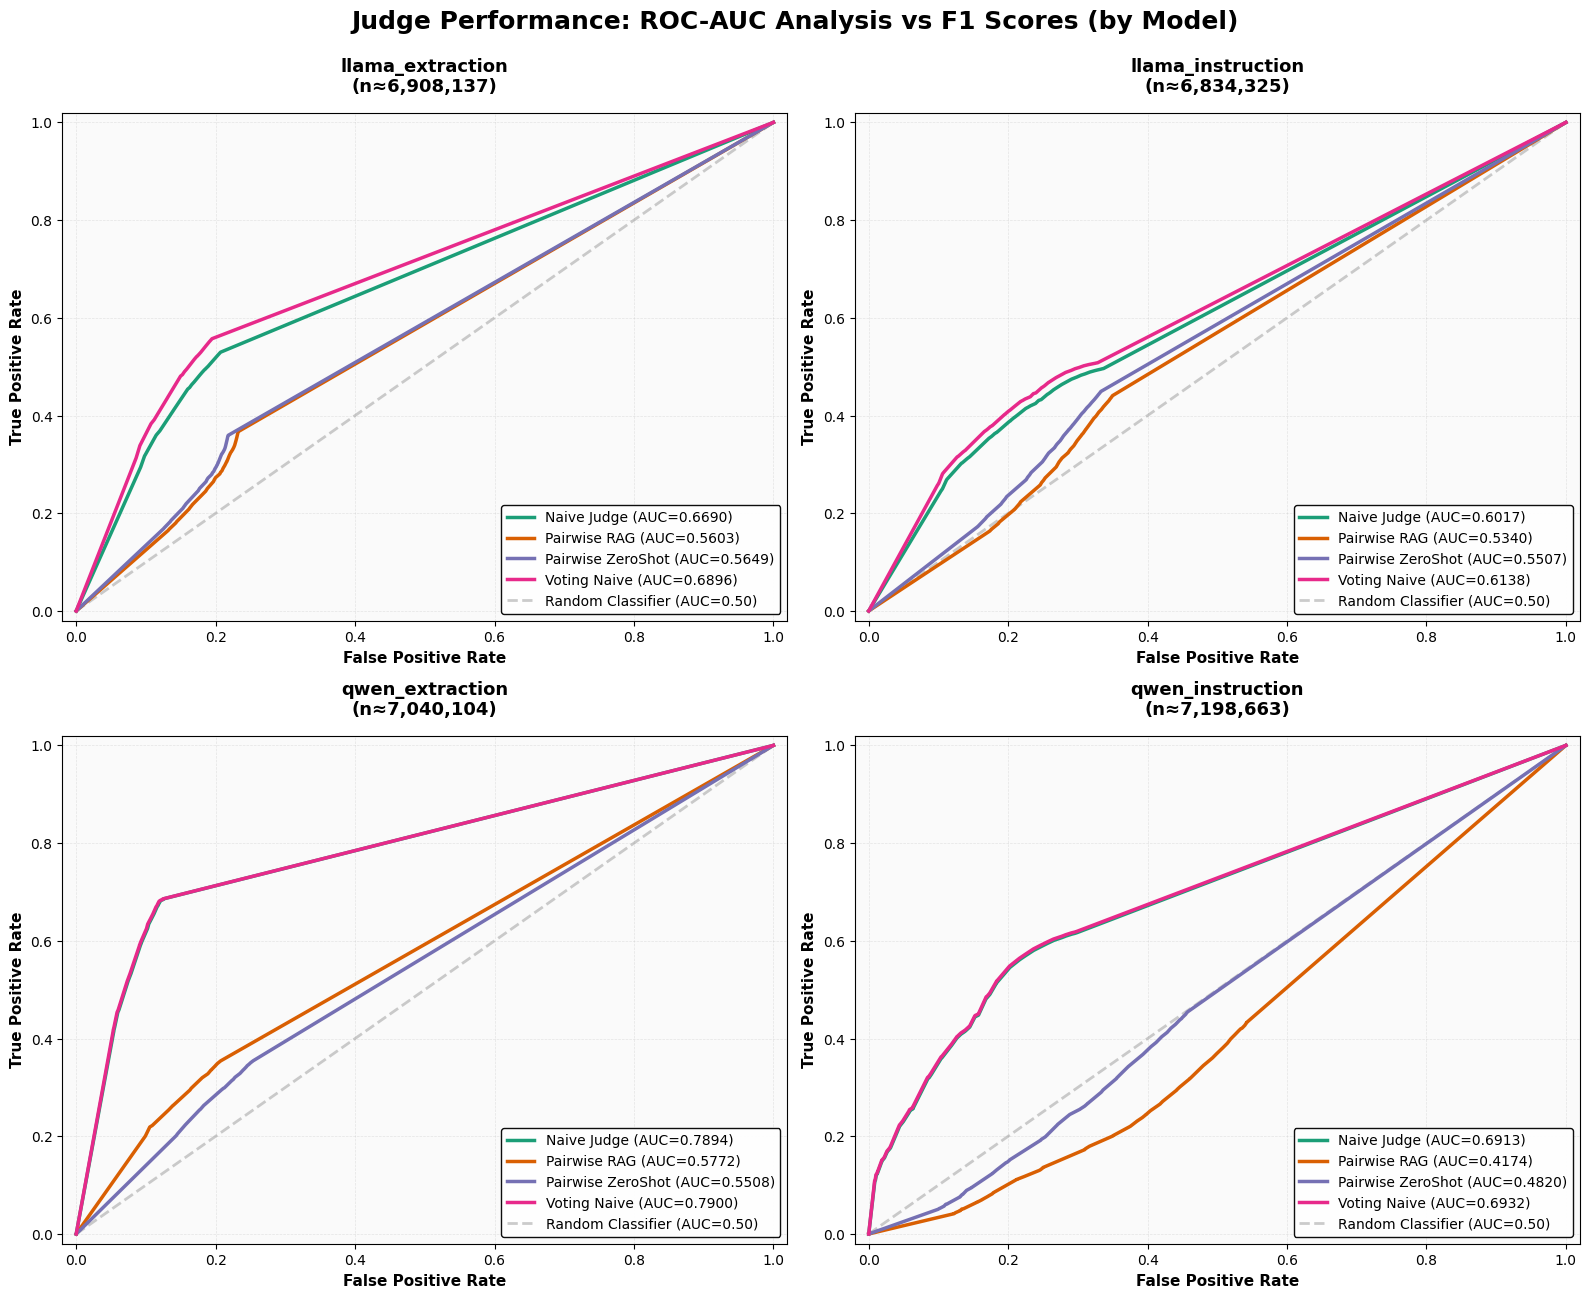


ROC-AUC Summary by Model and Judge

llama_extraction:
  Naive Judge               AUC=0.6690
  Pairwise RAG              AUC=0.5603
  Pairwise ZeroShot         AUC=0.5649
  Voting Naive              AUC=0.6896

llama_instruction:
  Naive Judge               AUC=0.6017
  Pairwise RAG              AUC=0.5340
  Pairwise ZeroShot         AUC=0.5507
  Voting Naive              AUC=0.6138

qwen_extraction:
  Naive Judge               AUC=0.7894
  Pairwise RAG              AUC=0.5772
  Pairwise ZeroShot         AUC=0.5508
  Voting Naive              AUC=0.7900

qwen_instruction:
  Naive Judge               AUC=0.6913
  Pairwise RAG              AUC=0.4174
  Pairwise ZeroShot         AUC=0.4820
  Voting Naive              AUC=0.6932

✓ Analysis complete!


In [12]:
print("\nStep 2: Generating 2x2 ROC-AUC grid...")
plot_models_roc_grid(
    model_folder_names=MODEL_FOLDER_NAMES,
    model_display_names=MODEL_DISPLAY_NAMES,
    judge_keys=JUDGE_KEYS,
    judge_display_names=JUDGES,
    auc_scores=auc_scores,
    processed_collections_root=PROCESSED_COLLECTIONS_PATH,
    reference_collections_root=REFERENCE_COLLECTIONS_PATH,
    judge_colors=JUDGE_COLORS
)

print("\n✓ Analysis complete!")

In [13]:
# Quick re-plotting without recomputing AUC (useful for tweaking visualizations)
# Uncomment below to re-plot using pre-computed AUC scores
"""
print("Loading pre-computed AUC scores for quick re-plotting...")
auc_scores_loaded = load_auc_scores()

if auc_scores_loaded:
    plot_models_roc_grid(
        model_folder_names=MODEL_FOLDER_NAMES,
        model_display_names=MODEL_DISPLAY_NAMES,
        judge_keys=JUDGE_KEYS,
        judge_display_names=JUDGES,
        auc_scores=auc_scores_loaded,
        processed_collections_root=PROCESSED_COLLECTIONS_PATH,
        reference_collections_root=REFERENCE_COLLECTIONS_PATH,
        judge_colors=JUDGE_COLORS
    )
"""
print("(Uncomment and run this cell to quickly re-plot using pre-computed AUC scores)")

(Uncomment and run this cell to quickly re-plot using pre-computed AUC scores)
